In [26]:
!pip install imblearn 
!pip install notebook ipython

In [30]:
!pip install shap lime joblib
!pip uninstall ipython -y
!pip install ipython


Found existing installation: ipython 9.2.0
Uninstalling ipython-9.2.0:
  Successfully uninstalled ipython-9.2.0
   ---------------------------------------- 0.0/611.0 kB ? eta -:--:--
   ---------------------------------- ----- 524.3/611.0 kB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 611.0/611.0 kB 2.2 MB/s  0:00:00


In [24]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.impute import KNNImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from imblearn.combine import SMOTETomek
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve




# saving
import joblib



In [10]:
# STEP 1: LOAD DATA
# ----------------
df = pd.read_csv("autism_screening.csv")  # Change filename to yours
print("Initial Shape:", df.shape)
print(df.head())

Initial Shape: (704, 21)
   A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0         1         1         1         1         0         0         1   
1         1         1         0         1         0         0         0   
2         1         1         0         1         1         0         1   
3         1         1         0         1         0         0         1   
4         1         0         0         0         0         0         0   

   A8_Score  A9_Score  A10_Score  ...  gender       ethnicity jundice austim  \
0         1         0          0  ...       f  White-European      no     no   
1         1         0          1  ...       m          Latino      no    yes   
2         1         1          1  ...       m          Latino     yes    yes   
3         1         0          1  ...       f  White-European      no    yes   
4         1         0          0  ...       f               ?      no     no   

   contry_of_res used_app_before result    

In [11]:
# ----------------
# STEP 2: CLEAN & ENCODE DATA
# ----------------

# Fix column names
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

# Encode categorical variables first
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Now handle missing values (numeric only)
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df[df.columns] = imputer.fit_transform(df)


In [12]:
# STEP 3: SPLIT DATA
# ----------------
X = df.drop("Class/ASD", axis=1)  # Change target column name if needed
y = df["Class/ASD"]

# Handle imbalance
smote_tomek = SMOTETomek(random_state=42)
X_res, y_res = smote_tomek.fit_resample(X, y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)


In [15]:
# STEP 4: MODEL TRAINING
# ----------------
models = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, kernel="rbf", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    results[name] = auc_scores
    print(f"{name} - Mean ROC-AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

Naive Bayes - Mean ROC-AUC: 0.9921 ± 0.0062
SVM - Mean ROC-AUC: 0.9966 ± 0.0014
Random Forest - Mean ROC-AUC: 1.0000 ± 0.0000
Extra Trees - Mean ROC-AUC: 1.0000 ± 0.0000



Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       103
         1.0       1.00      1.00      1.00       103

    accuracy                           1.00       206
   macro avg       1.00      1.00      1.00       206
weighted avg       1.00      1.00      1.00       206

ROC-AUC Score: 1.0


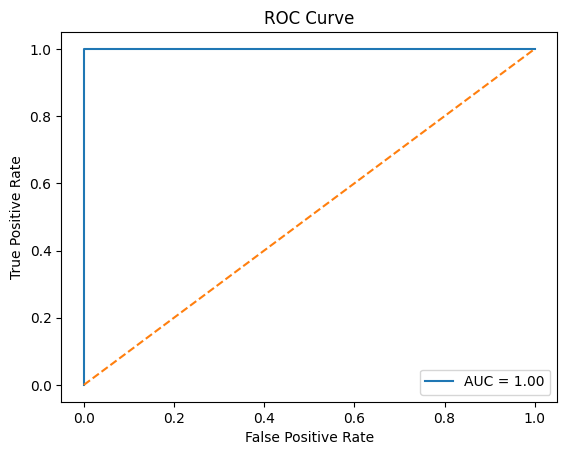

In [18]:
# ----------------
# STEP 5: EVALUATION ON TEST SET
# ----------------
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [38]:
# ----------------
# STEP 6: SHAP EXPLAINABILITY (FINAL FIX)
# ----------------
# Safe SHAP helper: version- and API-robust
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def safe_shap_analysis(best_model, X_train, X_test, out_prefix="shap", local_row_idx=0, topk=20):
    """
    Safe SHAP analysis and plotting for VS Code / scripts.
    Produces:
      - {out_prefix}_global_bar.png   (global importance by mean |SHAP|)
      - {out_prefix}_local_sample{local_row_idx}.png  (SHAP contributions for one sample)
      - {out_prefix}_values_test.csv  (all SHAP values for test set)
    Works with shap.Explainer() (new API) and TreeExplainer (fallback), and with both
    single-output and multi-class SHAP outputs.
    """
    # 1) Build explainer (try new unified API first, fallback to TreeExplainer)
    explainer = None
    shap_values_obj = None
    try:
        explainer = shap.Explainer(best_model, X_train)   # new style API (best effort)
        shap_values_obj = explainer(X_test)               # returns shap.Explanation object
    except Exception:
        try:
            explainer = shap.TreeExplainer(best_model)    # fallback
            shap_values_obj = explainer.shap_values(X_test)  # may be list or array (old API)
        except Exception as e:
            print("ERROR: Could not create SHAP explainer:", e)
            return

    # 2) Normalize to numpy array shap_arr shape (n_samples, n_features)
    if isinstance(shap_values_obj, list):
        # old API: list of arrays per class
        class_idx = 1 if len(shap_values_obj) > 1 else 0
        shap_arr = np.array(shap_values_obj[class_idx])  # (n_samples, n_features)
        base_value = getattr(explainer, "expected_value", None)
        if isinstance(base_value, (list, np.ndarray)) and len(base_value) > class_idx:
            base = base_value[class_idx]
        else:
            base = base_value
    else:
        # shap.Explanation object (new API)
        values = shap_values_obj.values  # could be shape (n_samples, n_features) or (n_samples, n_classes, n_features)
        base_value = shap_values_obj.base_values
        if values.ndim == 3:
            # (n_samples, n_classes, n_features) -> pick positive class if exists
            class_idx = 1 if values.shape[1] > 1 else 0
            shap_arr = values[:, class_idx, :]      # (n_samples, n_features)
            # base_value could be (n_samples, n_classes) or (n_classes,)
            if np.ndim(base_value) == 2:
                base = base_value[:, class_idx]
            else:
                base = base_value[class_idx] if np.ndim(base_value) > 0 else base_value
        else:
            # (n_samples, n_features)
            shap_arr = values
            base = base_value

    # 3) Get feature names
    if hasattr(X_test, "columns"):
        feature_names = list(X_test.columns)
    else:
        feature_names = [f"f{i}" for i in range(shap_arr.shape[1])]

    # Safety checks
    n_samples, n_features = shap_arr.shape
    if n_features != len(feature_names):
        print("Warning: feature count mismatch; adjusting feature names accordingly.")
        feature_names = feature_names[:n_features]

    # 4) Save full shap table for inspection
    shap_df = pd.DataFrame(shap_arr, columns=feature_names)
    shap_df.to_csv(f"{out_prefix}_values_test.csv", index=False)
    print(f"Saved SHAP values CSV: {out_prefix}_values_test.csv")

    # 5) Global importance (mean absolute SHAP)
    mean_abs = np.mean(np.abs(shap_arr), axis=0)
    order = np.argsort(mean_abs)[::-1]
    topk = min(topk, len(mean_abs))
    top_idx = order[:topk]
    plt.figure(figsize=(8, max(4, 0.35 * topk)))
    sns.barplot(x=mean_abs[top_idx], y=np.array(feature_names)[top_idx], palette="viridis")
    plt.xlabel("Mean |SHAP value|")
    plt.title("Global feature importance (mean |SHAP|)")
    plt.tight_layout()
    global_png = f"{out_prefix}_global_bar.png"
    plt.savefig(global_png, dpi=300)
    plt.close()
    print(f"Saved global importance plot: {global_png}")

    # 6) Local explanation for one instance (bar of per-feature contributions)
    local_idx = int(local_row_idx)
    if local_idx < 0 or local_idx >= n_samples:
        local_idx = 0
    local_shaps = shap_arr[local_idx]
    # construct df and sort by magnitude for clear plotting, keep sign for color
    df_local = pd.DataFrame({"feature": feature_names, "shap": local_shaps})
    df_local = df_local.sort_values(by="shap", key=lambda s: np.abs(s), ascending=True)  # so largest at top
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in df_local["shap"]]

    plt.figure(figsize=(8, max(4, 0.25 * len(feature_names))))
    plt.barh(df_local["feature"], df_local["shap"], color=colors)
    plt.xlabel("SHAP value (contribution to model output)")
    plt.title(f"Local SHAP contributions — sample {local_idx}")
    plt.tight_layout()
    local_png = f"{out_prefix}_local_sample{local_idx}.png"
    plt.savefig(local_png, dpi=300)
    plt.close()
    print(f"Saved local explanation plot: {local_png}")

    # 7) Nice summary message
    print("✔ SHAP analysis complete. Outputs:")
    print("   -", f"{out_prefix}_values_test.csv (all test SHAP values)")
    print("   -", global_png)
    print("   -", local_png)
    return {
        "shap_array": shap_arr,
        "feature_names": feature_names,
        "global_plot": global_png,
        "local_plot": local_png,
        "shap_csv": f"{out_prefix}_values_test.csv"
    }



In [39]:
# ----------------
# STEP 7: LIME EXPLAINABILITY
# ----------------
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=["No ASD", "ASD"],
    mode="classification"
)

i = 0  # First test instance
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=best_model.predict_proba
)

# Always save HTML for VS Code
html_path = "lime_explanation.html"
with open(html_path, "w", encoding="utf-8") as f:
    f.write(exp.as_html())
print(f"💾 LIME explanation saved to {html_path} — open it in your browser.")

# Save predictions
predictions_df = pd.DataFrame({"True_Label": y_test, "Predicted_Prob": y_pred_proba})
predictions_df.to_csv("ASD_predictions.csv", index=False)
print("✅ Predictions saved to ASD_predictions.csv")

💾 LIME explanation saved to lime_explanation.html — open it in your browser.
✅ Predictions saved to ASD_predictions.csv


In [40]:
# ----------------
# STEP 8: MODEL COMPARISON SUMMARY
# ----------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import joblib

# Example: If you have a dictionary of models (you can add the ones you trained)
models_to_compare = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results_list = []
for name, model in models_to_compare.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

model_comparison_df = pd.DataFrame(results_list)
model_comparison_df.to_csv("model_comparison.csv", index=False)
print("📊 Model comparison saved to model_comparison.csv")



📊 Model comparison saved to model_comparison.csv


In [41]:
# ----------------
# STEP 9: SAVE FINAL MODEL
# ----------------
joblib.dump(best_model, "asd_best_model.pkl")
print("💾 Best model saved to asd_best_model.pkl")

💾 Best model saved to asd_best_model.pkl


In [42]:
# ----------------
# STEP 10: SAVE ALL RESULTS / FIGURES
# ----------------
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

# ROC curve
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Best Model")
plt.savefig("roc_curve.png")
plt.close()
print("📈 ROC curve saved to roc_curve.png")

# Confusion matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No ASD", "ASD"])
disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.savefig("confusion_matrix.png")
plt.close()
print("📊 Confusion matrix saved to confusion_matrix.png")

# SHAP summary plot already created in step 6
# LIME explanation saved in step 7
print("✅ All results and figures saved.")

📈 ROC curve saved to roc_curve.png
📊 Confusion matrix saved to confusion_matrix.png
✅ All results and figures saved.


In [43]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from imblearn.combine import SMOTETomek

import shap
from lime.lime_tabular import LimeTabularExplainer

# ----------------
# STEP 1: LOAD DATA
# ----------------
df = pd.read_csv("autism_screening.csv")
print("Initial Shape:", df.shape)

# ----------------
# STEP 2: CLEAN & ENCODE DATA
# ----------------
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

imputer = KNNImputer(n_neighbors=5)
df[df.columns] = imputer.fit_transform(df)

# ----------------
# STEP 3: SPLIT DATA
# ----------------
X = df.drop("Class/ASD", axis=1)
y = df["Class/ASD"]

smote_tomek = SMOTETomek(random_state=42)
X_res, y_res = smote_tomek.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# ----------------
# STEP 4: MODEL TRAINING
# ----------------
models = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, kernel="rbf", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{name} - Mean ROC-AUC: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")

# Choose best model (Random Forest here)
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)

# ----------------
# STEP 5: EVALUATION
# ----------------
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_pred_proba):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png", dpi=300)
plt.close()
print("ROC Curve saved to roc_curve.png")

# ----------------
# STEP 6: SHAP EXPLAINABILITY
# ----------------
try:
    explainer = shap.Explainer(best_model, X_train)
    shap_values = explainer(X_test)
    shap.summary_plot(shap_values, X_test, show=False)
    plt.savefig("shap_summary.png", dpi=300)
    plt.close()
    print("SHAP summary plot saved to shap_summary.png")
except Exception as e:
    print("⚠️ SHAP failed:", e)

# ----------------
# STEP 7: LIME EXPLAINABILITY
# ----------------
lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=["No ASD", "ASD"],
    mode="classification"
)
exp = lime_explainer.explain_instance(
    data_row=X_test.iloc[0],
    predict_fn=best_model.predict_proba
)
with open("lime_explanation.html", "w", encoding="utf-8") as f:
    f.write(exp.as_html())
print("LIME explanation saved to lime_explanation.html")

# ----------------
# STEP 8: MODEL COMPARISON SUMMARY
# ----------------
models_to_compare = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results_list = []
for name, model in models_to_compare.items():
    model.fit(X_train, y_train)
    y_pred_cmp = model.predict(X_test)
    y_proba_cmp = model.predict_proba(X_test)[:, 1]
    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_cmp),
        "Precision": precision_score(y_test, y_pred_cmp),
        "Recall": recall_score(y_test, y_pred_cmp),
        "ROC-AUC": roc_auc_score(y_test, y_proba_cmp)
    })

model_comparison_df = pd.DataFrame(results_list)
model_comparison_df.to_csv("model_comparison.csv", index=False)
print("📊 Model comparison saved to model_comparison.csv")

# ----------------
# STEP 9: SAVE MODEL & PREPROCESSING
# ----------------
joblib.dump(best_model, "asd_best_model.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
with open("feature_columns.json", "w") as f:
    json.dump(list(X.columns), f)
print("💾 Best model and preprocessing saved.")

# ----------------
# STEP 10: SAVE FIGURES
# ----------------
# ROC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC Curve - Best Model")
plt.savefig("roc_curve.png")
plt.close()

# Confusion matrix
cm = confusion_matrix(y_test, best_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No ASD", "ASD"])
disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.savefig("confusion_matrix.png")
plt.close()
print("📊 Confusion matrix saved to confusion_matrix.png")

print("✅ All results, figures, and model files saved.")


Initial Shape: (704, 21)
Naive Bayes - Mean ROC-AUC: 0.9921 ± 0.0062
SVM - Mean ROC-AUC: 0.9966 ± 0.0014
Random Forest - Mean ROC-AUC: 1.0000 ± 0.0000
Extra Trees - Mean ROC-AUC: 1.0000 ± 0.0000

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       103
         1.0       1.00      1.00      1.00       103

    accuracy                           1.00       206
   macro avg       1.00      1.00      1.00       206
weighted avg       1.00      1.00      1.00       206

ROC-AUC Score: 1.0
ROC Curve saved to roc_curve.png
SHAP summary plot saved to shap_summary.png
LIME explanation saved to lime_explanation.html
📊 Model comparison saved to model_comparison.csv
💾 Best model and preprocessing saved.
📊 Confusion matrix saved to confusion_matrix.png
✅ All results, figures, and model files saved.
